IMAGES

In [1]:
import os
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")
dataset_dir = os.path.join(path, "training_set", "training_set")

if not os.path.isdir(dataset_dir):
    dataset_dir = os.path.join(path, "training_set")

if not os.path.isdir(dataset_dir):
    raise FileNotFoundError(f"Could not find training images under {path}")

print(dataset_dir)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 218M/218M [06:20<00:00, 600kB/s] 

Extracting files...


C:\Users\HP\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1\training_set\training_set


In [7]:
import tensorflow as tf


ds = tf.keras.preprocessing.image_dataset_from_directory(dataset_dir, image_size=(160, 160), batch_size=32)
print(ds.class_names)

Found 8005 files belonging to 2 classes.
['cats', 'dogs']


In [8]:
dataset_size = len(ds)

if dataset_size < 3:
    raise ValueError("Dataset must contain at least 3 batches to create train, validation, and test splits.")

train = max(1, int(0.8 * dataset_size))
val = max(1, int(0.1 * dataset_size))
test = dataset_size - train - val

if test < 1:
    test = 1
    remaining = dataset_size - test
    train = max(1, int(0.8 * remaining))
    val = remaining - train
    if val < 1:
        val = 1
        train = remaining - val

train_ds = ds.take(train)
val_ds = ds.skip(train).take(val)
test_ds = ds.skip(train + val).take(test)

norm = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (norm(x), y))
val_ds = val_ds.map(lambda x, y: (norm(x), y))
test_ds = test_ds.map(lambda x, y: (norm(x), y))

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(160, 160, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 206ms/step - accuracy: 0.5280 - loss: 1.9075 - val_accuracy: 0.5125 - val_loss: 0.9404
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.5259 - loss: 0.8419 - val_accuracy: 0.5362 - val_loss: 0.6838
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.5591 - loss: 0.7075 - val_accuracy: 0.5138 - val_loss: 0.7427
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 190ms/step - accuracy: 0.5436 - loss: 0.7219 - val_accuracy: 0.5562 - val_loss: 0.6803
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 201ms/step - accuracy: 0.5672 - loss: 0.6809 - val_accuracy: 0.5987 - val_loss: 0.6650
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.5664 - loss: 0.6892 - val_accuracy: 0.5437 - val_loss: 0.6937
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 206ms/step - accuracy: 0.5775 - loss: 0.6779 - val_accuracy: 0.6087 - val_loss: 0.6569
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 200ms/step - accuracy: 0.5336 - loss: 0

In [9]:
loss,acc=model.evaluate(test_ds)

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5043 - loss: 0.6927


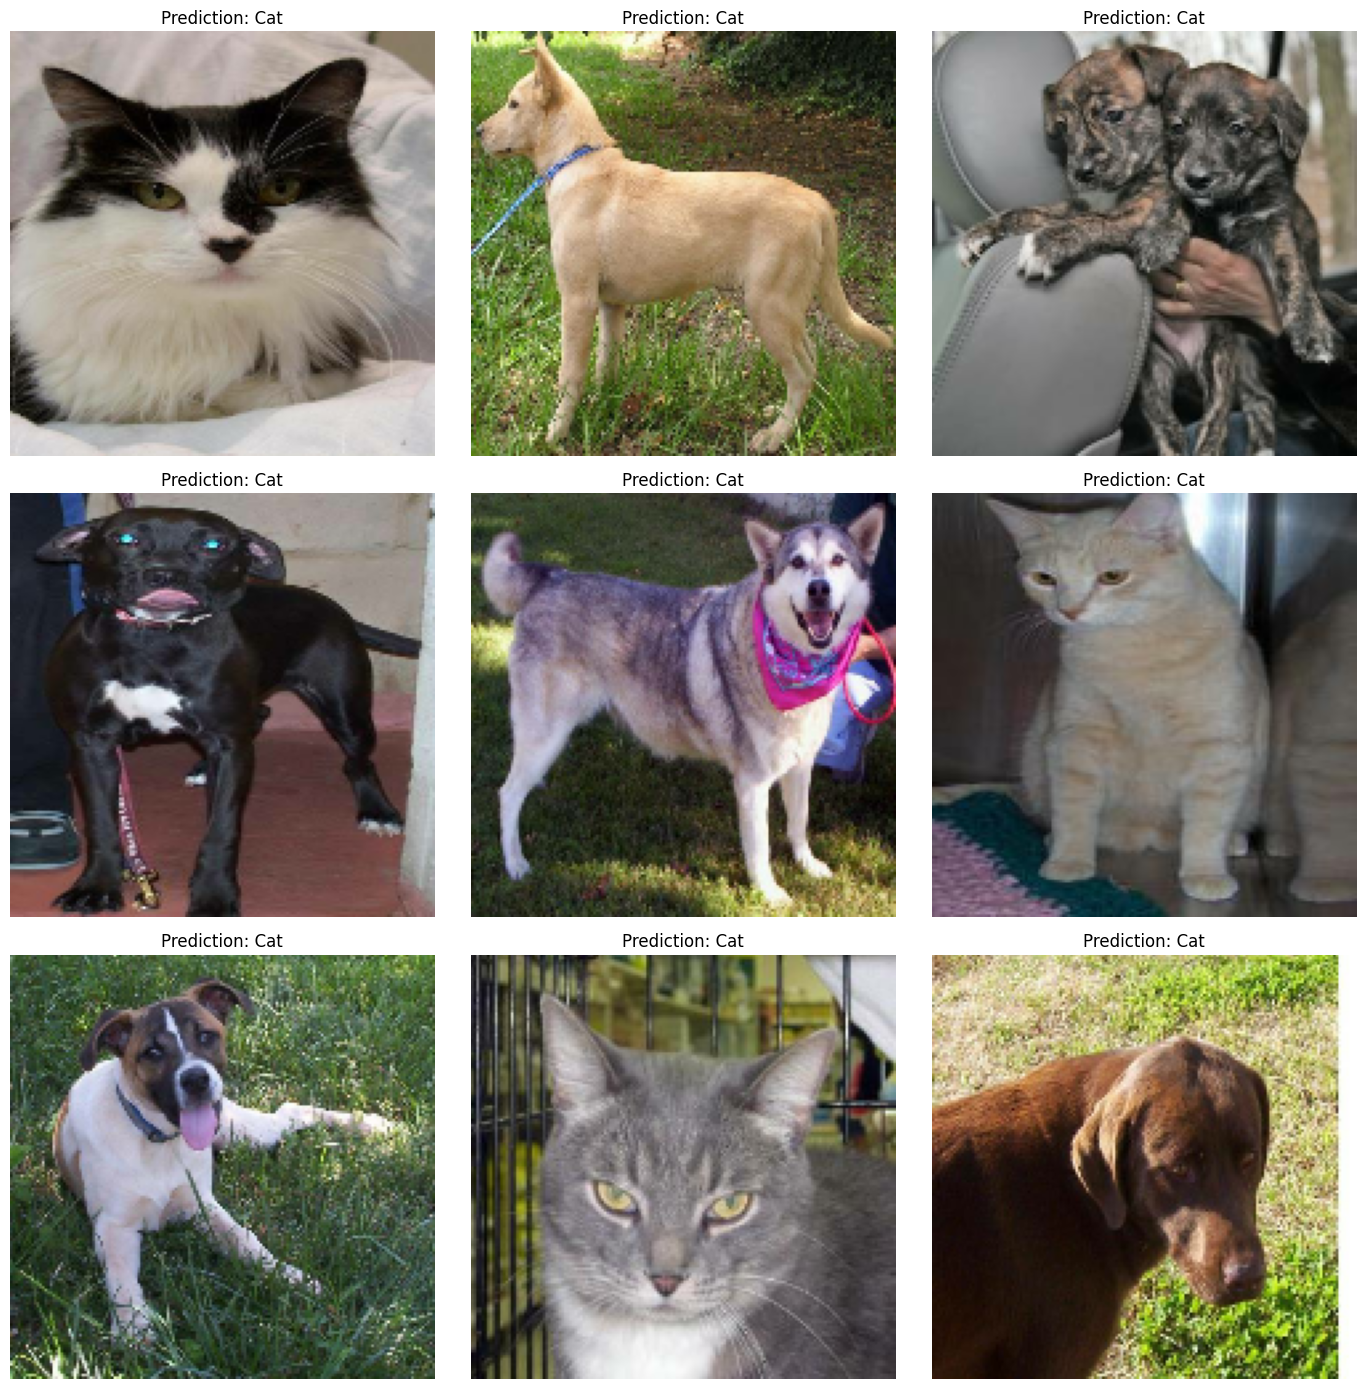

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

plt.figure(figsize=(12, 12), dpi=120)

for images, labels in test_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        img = images[i]  # normalized float image in 0..1
        img_display = tf.image.resize(img, (256, 256))
        plt.imshow(tf.cast(img_display * 255, tf.uint8).numpy(), interpolation='nearest')
        prediction_score = model.predict(images[i:i+1], verbose=0)[0][0]
        prediction_label = "Dog" if prediction_score > 0.5 else "Cat"
        true_label = ds.class_names[int(labels[i].numpy())]
        plt.title(f"True: {true_label} | Pred: {prediction_label} ({prediction_score:.2f})", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()